# From NIR to FPGA

In this notebook we take the saved LIF neuron graphs and source recordings from
`1-definition.ipynb` and push them through the **NIR2FPGA** (N2F) pipeline.
N2F normalises the NIR graph, calibrates fixed-point quantization, and generates
AXI4-Stream packets ready for hardware compilation. This notebook covers:

1. Loading the saved NIR graphs, dataset, and source recordings.
2. Defining the discretization choices (bit-width, MAC width, PTQ options).
3. For each simulator (Norse, Sinabs, JAX — TODO):
   - Running the N2F pipeline.
   - Evaluating spike equivalence via `n2f.transformation.evaluate()`.
   - Calling the (future) hardware simulation stub `n2f.simulate()`.
   - Plotting per-layer recordings with the built-in visualiser.
4. A cross-simulator side-by-side comparison of membrane voltage traces.
5. A cumulative R² plot showing quantization fidelity over time.

## Imports

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import nir
import numpy as np
import torch
from torch.utils.data import TensorDataset

from InternalSimulator import NIR2FPGA
from InternalSimulator.DiscretizationChoices import DiscretizationChoices, PTQOptions
from InternalSimulator.PredictionType import OutputEqual

torch.manual_seed(42)

output_dir = Path("./outputs")
norse_dir  = output_dir / "norse"
sinabs_dir = output_dir / "sinabs"
output_dir.mkdir(parents=True, exist_ok=True)

# 1. Load saved files

All files were written by `1-definition.ipynb`.

In [10]:
# Dataset: shape (num_samples, timesteps, inputs) = (10, 200, 1)
dataset_np     = np.load(str(output_dir / "dataset.npy"))        # (10, 200, 1)
dataset_tensor = torch.from_numpy(dataset_np).float()

NUM_SAMPLES = dataset_tensor.shape[0]   # 10
TIMESTEPS   = dataset_tensor.shape[1]   # 200
SAMPLE_IDX  = NUM_SAMPLES // 2          # mid-range amplitude sample

print(f"Dataset: {dataset_tensor.shape}  — using sample {SAMPLE_IDX} as representative")

Dataset: torch.Size([10, 200, 1])  — using sample 5 as representative


In [11]:
# Norse LIF
nir_lif_norse  = nir.read(str(norse_dir  / "lif.nir"))
norse_lif_rec  = np.load(str(norse_dir   / "lif_rec.npz"))   # keys: v_mem, spikes

# Sinabs LIF
nir_lif_sinabs = nir.read(str(sinabs_dir / "lif.nir"))
sinabs_lif_rec = np.load(str(sinabs_dir  / "lif_rec.npz"))   # keys: v_mem, spikes

# JAX LIF — TODO: Jens
# nir_lif_jax = nir.read(str(output_dir / "jax" / "lif.nir"))
# jax_lif_rec = np.load(str(output_dir  / "jax" / "lif_rec.npz"))

print("Loaded NIR graphs and source recordings.")
print(f"  Norse v_mem shape : {norse_lif_rec['v_mem'].shape}")
print(f"  Sinabs v_mem shape: {sinabs_lif_rec['v_mem'].shape}")

Loaded NIR graphs and source recordings.
  Norse v_mem shape : (200, 1)
  Sinabs v_mem shape: (200, 1)


In [12]:
def to_n2f_source(rec: "np.lib.npyio.NpzFile", layer_id: str = "0") -> dict:  # type: ignore[type-arg]
    """Convert an npz recording dict to the N2F source-recording format."""
    v_mem  = torch.from_numpy(rec["v_mem"].copy()).float()    # (T, 1)
    spikes = torch.from_numpy(rec["spikes"].copy()).float()   # (T, 1)
    return {
        layer_id: {"v_mem": v_mem, "output": spikes},
        "output": {"input": spikes},
    }

# 2. Discretization Choices

The `DiscretizationChoices` object bundles every parameter that governs
fixed-point quantization and hardware generation.

| Parameter | Description |
|-----------|-------------|
| `total_bits` | **Bit-width target** for all fixed-point formats (weights, activations, membrane). E.g. `16` gives SQ3.13 weights and SQ4.12 activations for a typical LIF. |
| `macWidth` | **Hardware MAC width** — the number of multiplier bits in the dataflow accelerator. Must be ≤ `total_bits`. Controls throughput vs area. |
| `dataset` | **Calibration data** — a `TensorDataset(samples, labels)` used by the PTQ algorithm to compute activation ranges. Passed as the primary dataset when no separate PTQ dataset is provided via `ptq`. |
| `representative_sample_index` | Index into `dataset` of the sample used to record per-layer activations and generate AXI input packets. |
| `ptq` | **`PTQOptions`** — controls the post-training quantization algorithm: |
|       | • `method`: `"minmax"` or `"percentile"` |
|       | • `percentile`: percentile value when `method="percentile"` |
|       | • `threshold_headroom_multiplier`: safety margin above the measured spike threshold |
|       | • `readout_percentile`: clipping percentile for LI/ExpLeak readout ranges |
|       | • `histogram_bins`: number of bins for the calibration histogram |
|       | • `histogram_sample_stride`: subsample stride when building the histogram |

In [13]:
dc_dataset = TensorDataset(
    dataset_tensor,
    torch.zeros(NUM_SAMPLES, dtype=torch.long),  # no classification labels needed
)

dc = DiscretizationChoices(
    timesteps=TIMESTEPS,
    dataset=dc_dataset,
    batch_size=NUM_SAMPLES,
    total_bits=16,
    macWidth=4,
    representative_sample_index=SAMPLE_IDX,
    ptq=PTQOptions(method="minmax"),
)

# 3. Norse

In [14]:
norse_source = to_n2f_source(norse_lif_rec)
n2f_norse = NIR2FPGA("iscas-lif-norse", nir_lif_norse, dc)
n2f_norse.report_quantization()

Quantization data of network "iscas-lif-norse"
0:
	input: UQ5.11
	output: UQ1.0
	v_mem: UQ2.14
	i_syn: UQ1.15


## Evaluate

In [15]:
n2f_norse.add_recording("source", norse_source)
try:
    n2f_norse.transformation.evaluate(OutputEqual())
except Exception as e:
    print(f"evaluate() (Norse): {e}")

evaluate() (Norse): The size of tensor a (200) must match the size of tensor b (10) at non-singleton dimension 1


## Save the files

In [18]:
n2f_norse.save_files()

Wrote iscas-lif-norse/model.nir, iscas-lif-norse/model.json, iscas-lif-norse/quantizations.json, iscas-lif-norse/compilation.json, iscas-lif-norse/input.npy, and iscas-lif-norse/output.npy.


## Simulate 

In [19]:
try:
    n2f_norse.simulate()
except NotImplementedError as e:
    print(f"simulate() (Norse): {e}")

FileNotFoundError: [HardwareSimulation] Model files not found at /home/mrontio/uni/phd/src/nir-fpga-hackathon/2-compilation/inputs/iscas-lif-norse. Call save_files() first.

## Plot

In [11]:
n2f_norse.plot_recordings(
    "0",
    neuron_idx=0,
    filename=str(norse_dir / "n2f.png"),
    ignorelist=["behavioural"],
    plot_size=(20, 10),
)

# 3. LIF — Sinabs

In [12]:
sinabs_source = to_n2f_source(sinabs_lif_rec)
n2f_sinabs = NIR2FPGA("iscas-lif-sinabs", nir_lif_sinabs, dc)
n2f_sinabs.report_quantization()

Quantization data of network "iscas-lif-sinabs"
0:
	input: UQ5.11
	output: UQ1.0
	v_mem: UQ2.14
	i_syn: UQ1.15


## 5. Evaluate — Sinabs

In [13]:
n2f_sinabs.add_recording("source", sinabs_source)
try:
    n2f_sinabs.transformation.evaluate(OutputEqual())
except Exception as e:
    print(f"evaluate() (Sinabs): {e}")

evaluate() (Sinabs): The size of tensor a (200) must match the size of tensor b (10) at non-singleton dimension 1


## 6. Simulate — Sinabs

In [14]:
try:
    n2f_sinabs.simulate()
except NotImplementedError as e:
    print(f"simulate() (Sinabs): {e}")

simulate() (Sinabs): simulate() will be implemented in a later step


## 7. Plot recordings — Sinabs

In [15]:
n2f_sinabs.plot_recordings(
    "0",
    neuron_idx=0,
    filename=str(sinabs_dir / "n2f.png"),
    ignorelist=["behavioural"],
    plot_size=(20, 10),
)

# 3. LIF — JAX (TODO)

In [16]:
# TODO: Jens — JAX N2F section
# jax_dir    = output_dir / "jax"
# jax_source = to_n2f_source(jax_lif_rec)
# n2f_jax = NIR2FPGA("iscas-lif-jax", nir_lif_jax, dc)
# n2f_jax.report_quantization()
# n2f_jax.add_recording("source", jax_source)
# n2f_jax.transformation.evaluate(OutputEqual())
# try:
#     n2f_jax.simulate()
# except NotImplementedError as e:
#     print(f"simulate() (JAX): {e}")
# n2f_jax.plot_recordings("0", neuron_idx=0, filename=str(jax_dir / "n2f.png"),
#                         ignorelist=["behavioural"], plot_size=(20, 10))

# 8. Cross-simulator comparison

In [17]:
def get_v_mem(rec_dict: dict, layer_id: str = "0") -> np.ndarray:  # type: ignore[type-arg]
    """Extract v_mem from an N2F rec_dict stage as a 1-D numpy array."""
    v = rec_dict[layer_id]["v_mem"]
    if torch.is_tensor(v):
        v = v.detach().cpu().numpy()
    return np.asarray(v).squeeze()

def compute_r2(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    return 1.0 - ss_res / ss_tot if ss_tot != 0.0 else float("nan")

def cumulative_r2(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    """R²(source[0:t], quantized[0:t]) for t = 2 … T."""
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    r2s = np.full(len(y_true), np.nan)
    for t in range(2, len(y_true) + 1):
        yt, yp = y_true[:t], y_pred[:t]
        ss_res = np.sum((yt - yp) ** 2)
        ss_tot = np.sum((yt - np.mean(yt)) ** 2)
        r2s[t - 1] = 1.0 - ss_res / ss_tot if ss_tot != 0.0 else np.nan
    return r2s

In [18]:
# Extract v_mem for all simulators (source and quantized)
v_src_norse    = get_v_mem(norse_source)
v_int_norse    = get_v_mem(n2f_norse.rec_dict["internal"])
v_quant_norse  = get_v_mem(n2f_norse.rec_dict["quantized"])

v_src_sinabs   = get_v_mem(sinabs_source)
v_int_sinabs   = get_v_mem(n2f_sinabs.rec_dict["internal"])
v_quant_sinabs = get_v_mem(n2f_sinabs.rec_dict["quantized"])

# JAX — uncomment once implemented
# v_src_jax    = get_v_mem(jax_source)
# v_int_jax    = get_v_mem(n2f_jax.rec_dict["internal"])
# v_quant_jax  = get_v_mem(n2f_jax.rec_dict["quantized"])

simulators = [
    ("Norse",  v_src_norse,  v_int_norse,  v_quant_norse),
    ("Sinabs", v_src_sinabs, v_int_sinabs, v_quant_sinabs),
    # ("JAX", v_src_jax, v_int_jax, v_quant_jax),  # TODO
]

# Print R² summary
print("Simulator Comparison — R² (v_mem)")
print("=" * 50)
for name, v_src, v_int, v_quant in simulators:
    r2_src_int   = compute_r2(v_src, v_int)
    r2_src_quant = compute_r2(v_src, v_quant)
    r2_int_quant = compute_r2(v_int, v_quant)
    print(f"\n{name}:")
    print(f"  R² source → internal  : {r2_src_int:.6f}")
    print(f"  R² source → quantized : {r2_src_quant:.6f}")
    print(f"  R² internal → quantized: {r2_int_quant:.6f}")

Simulator Comparison — R² (v_mem)

Norse:
  R² source → internal  : 0.554351
  R² source → quantized : 0.554839
  R² internal → quantized: 0.999999

Sinabs:
  R² source → internal  : 1.000000
  R² source → quantized : 0.999999
  R² internal → quantized: 0.999999


## 8a. Side-by-side membrane voltage comparison

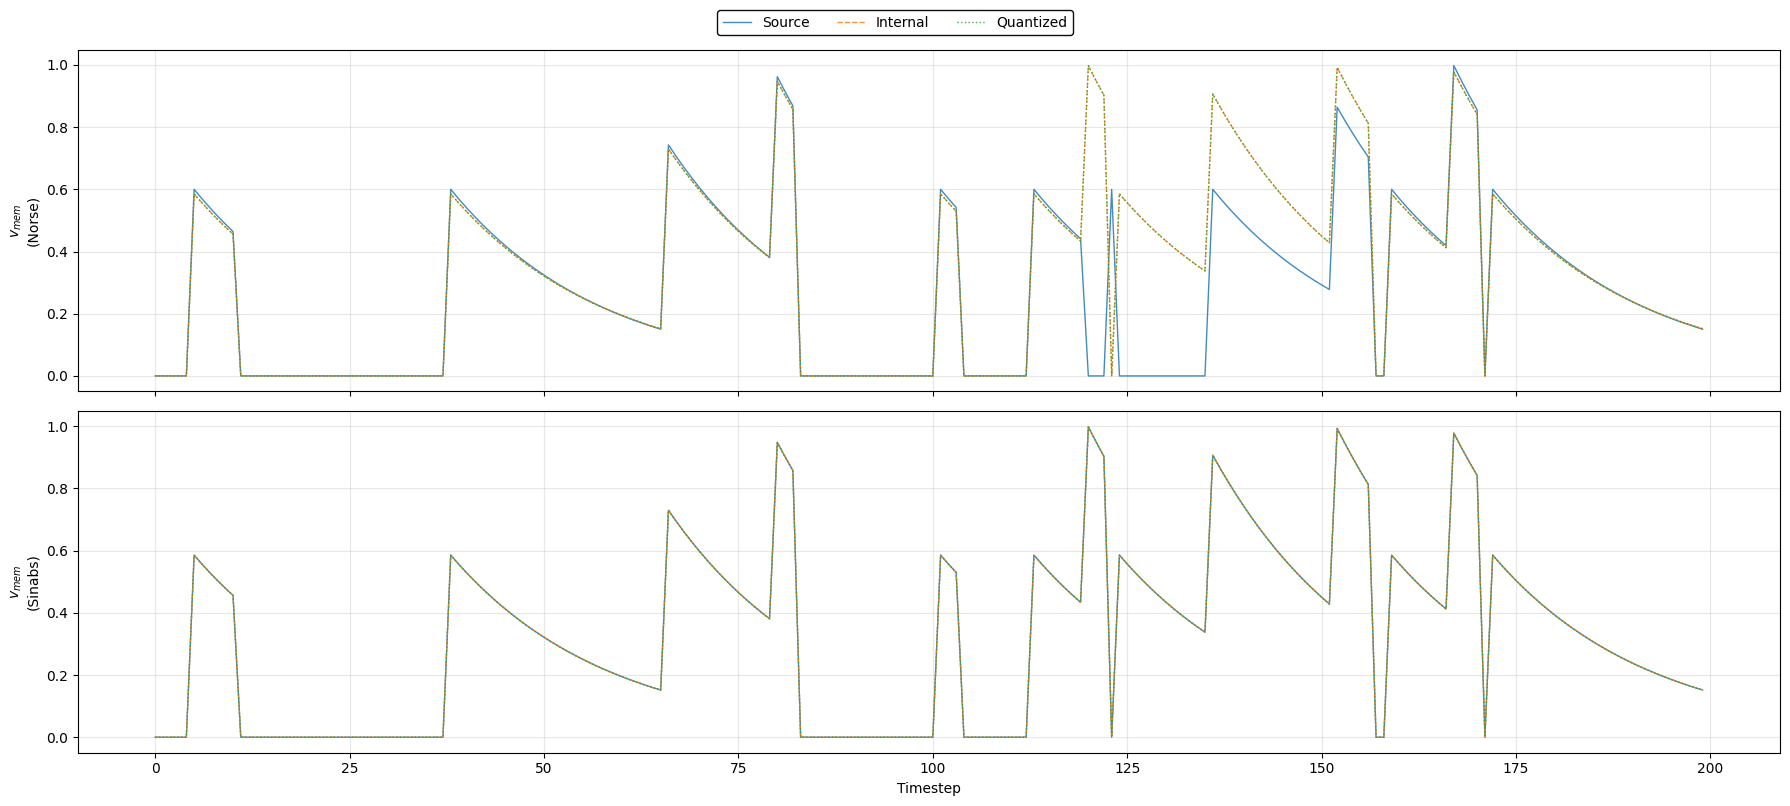

Saved comparison.png


In [19]:
time = np.arange(TIMESTEPS)

fig, axes = plt.subplots(len(simulators), 1, figsize=(18, 4 * len(simulators)), sharex=True)
if len(simulators) == 1:
    axes = [axes]

for ax, (name, v_src, v_int, v_quant) in zip(axes, simulators):
    ax.plot(time, v_src,   label="Source",    linewidth=1.0, alpha=0.85, linestyle="-")
    ax.plot(time, v_int,   label="Internal",  linewidth=1.0, alpha=0.85, linestyle="--")
    ax.plot(time, v_quant, label="Quantized", linewidth=1.0, alpha=0.85, linestyle=":")
    ax.set_ylabel(f"$v_{{mem}}$\n({name})")
    ax.grid(True, alpha=0.3)

handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.01),
           frameon=True, framealpha=0.95, edgecolor="black")
for ax in axes:
    if ax.get_legend():
        ax.get_legend().remove()

axes[-1].set_xlabel("Timestep")
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.savefig(str(output_dir / "comparison.png"), dpi=150)
plt.show()
print("Saved comparison.png")

## 8b. Cumulative R² — source vs quantized

Each line shows R²(source[0:t], quantized[0:t]) as it evolves over time.
A line that quickly reaches 1.0 means the quantized network tracks the source
membrane voltage faithfully from the very first timestep.

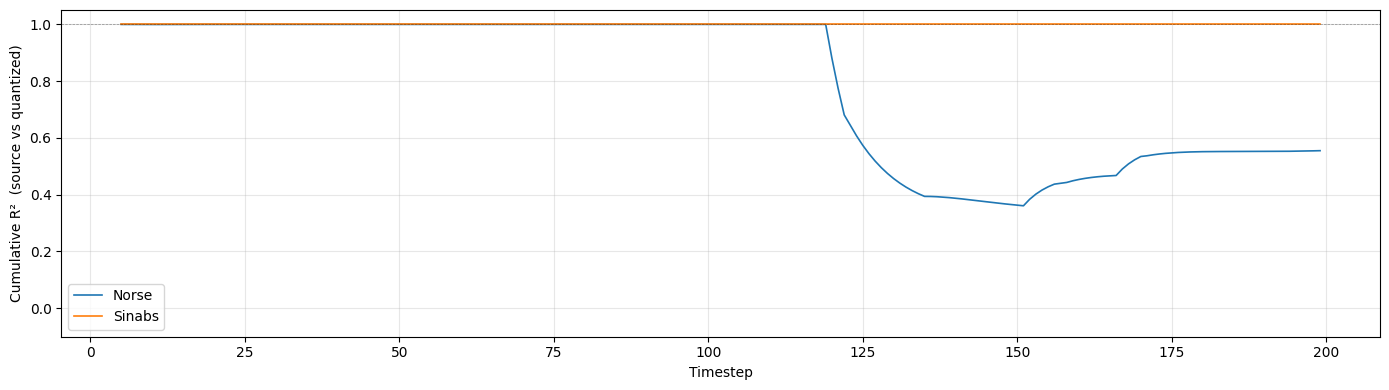

Saved r2.png


In [20]:
fig, ax = plt.subplots(figsize=(14, 4))

for name, v_src, _, v_quant in simulators:
    r2_curve = cumulative_r2(v_src, v_quant)
    ax.plot(time, r2_curve, label=name, linewidth=1.2)

ax.set_xlabel("Timestep")
ax.set_ylabel("Cumulative R²  (source vs quantized)")
ax.set_ylim(-0.1, 1.05)
ax.axhline(1.0, color="black", linewidth=0.5, linestyle="--", alpha=0.4)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(output_dir / "r2.png"), dpi=150)
plt.show()
print("Saved r2.png")